# Notebook 05 — Evaluation comparative Phase 6

**Projet :** Juste des Ventilateurs — M2 Data/IA LaPlateforme_  
**Phase :** 6 — Boucle fermee et evaluation comparative  
**Objectif :** Comparer les 3 modes de supervision et analyser la robustesse par scenario.

## Modes compares
| Mode | Predicteur | Controleur | Description |
|------|-----------|------------|-------------|
| `native` | Aucun | Auto jumeaux-chauds | Baseline de reference |
| `threshold` | Aucun | Seuils fixes | Baseline regles simples |
| `ml` | Logistic (failure_60s) | Supervised + override | Recommande Phase 6 |

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

_root = Path.cwd()
for _candidate in [_root, _root.parent, _root.parent.parent]:
    if (_candidate / 'evaluation').exists() and (_candidate / 'supervisor').exists():
        _root = _candidate
        break
os.chdir(_root)
sys.path.insert(0, str(_root))

RESULTS_DIR = Path('evaluation/results')
print(f'Repertoire : {Path.cwd()}')

Repertoire : C:\AIDEV\LaPlateforme_\juste-des-ventilateurs


## 1. Chargement des resultats

In [2]:
with open(RESULTS_DIR / 'benchmark_results.json') as f:
    bench = json.load(f)
with open(RESULTS_DIR / 'robustness_results.json') as f:
    rob = json.load(f)

df_bench = pd.DataFrame(bench['results']).set_index('mode')
df_rob   = pd.DataFrame(rob['results']).set_index('scenario')

print(f"Benchmark : label={bench['label']}  n_test={bench['n_test']:,}  risk_thr={bench['risk_thr']}")
print(f"Robustesse : {len(df_rob)} scenarios")

cols_bench = ['mean_rpm','mean_power_fans_w','t_mean','t_max','pct_critical',
              'action_accuracy','high_rpm_when_dangerous','median_lead_time_s',
              'n_incidents_detected','n_incidents_total']
display(df_bench[cols_bench].style
    .highlight_max(subset=['action_accuracy','high_rpm_when_dangerous',
                            'median_lead_time_s','n_incidents_detected'], color='#c8f7c5')
    .highlight_min(subset=['mean_rpm','mean_power_fans_w'], color='#fef9c3')
    .format({
        'mean_rpm':'{:.0f}', 'mean_power_fans_w':'{:.1f} W',
        't_mean':'{:.1f} C', 't_max':'{:.1f} C',
        'pct_critical':'{:.1%}', 'action_accuracy':'{:.3f}',
        'high_rpm_when_dangerous':'{:.3f}',
        'median_lead_time_s':'{:.0f} s',
    })
    .set_caption('Benchmark comparatif — 3 modes (offline replay)'))

Benchmark : label=failure_60s  n_test=45,621  risk_thr=0.6
Robustesse : 7 scenarios


,mean_rpm,mean_power_fans_w,t_mean,t_max,pct_critical,action_accuracy,high_rpm_when_dangerous,median_lead_time_s,n_incidents_detected,n_incidents_total
mode,,,,,,,,,,
native,984,5.8 W,55.3 C,88.0 C,0.0%,0.200,0.000,0 s,0,7986
threshold,1815,30.3 W,55.3 C,88.0 C,0.0%,0.417,0.105,0 s,0,7986
ml,2681,116.7 W,55.3 C,88.0 C,0.0%,0.786,1.000,120 s,7981,7986


## 2. Comparaison visuelle des 3 modes

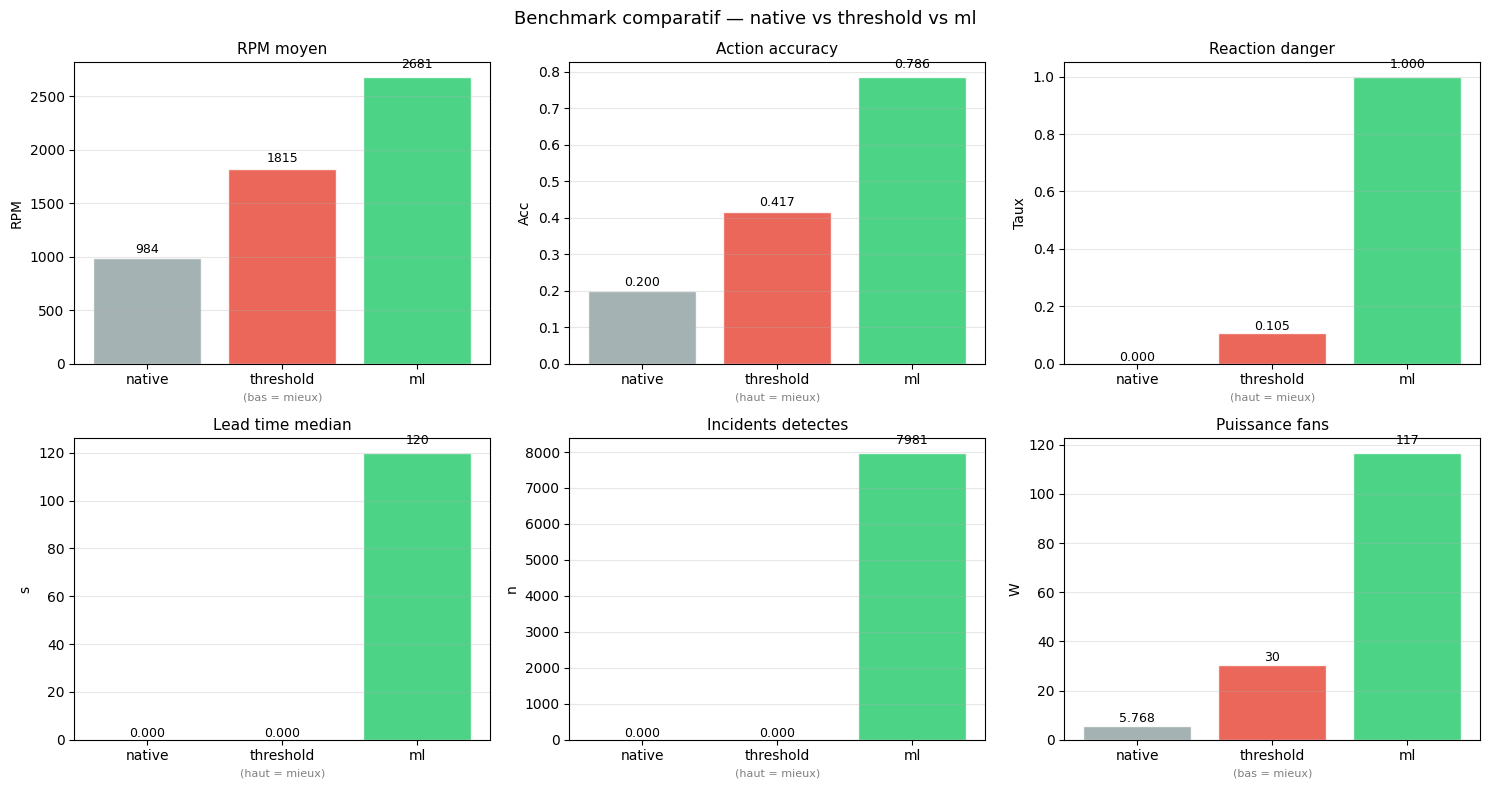

Figure sauvegardee.


In [3]:
modes  = list(df_bench.index)
colors = {'native': '#95a5a6', 'threshold': '#e74c3c', 'ml': '#2ecc71'}
clrs   = [colors.get(m, '#aaa') for m in modes]
x      = np.arange(len(modes))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metrics = [
    ('mean_rpm',               'RPM moyen',           'RPM',  False),
    ('action_accuracy',        'Action accuracy',     'Acc',  True),
    ('high_rpm_when_dangerous','Reaction danger',     'Taux', True),
    ('median_lead_time_s',     'Lead time median',    's',    True),
    ('n_incidents_detected',   'Incidents detectes',  'n',    True),
    ('mean_power_fans_w',      'Puissance fans',      'W',    False),
]

for ax, (col, title, unit, higher_better) in zip(axes.flatten(), metrics):
    vals = df_bench[col].values
    bars = ax.bar(x, vals, color=clrs, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(unit)
    ax.set_xticks(x)
    ax.set_xticklabels(modes, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.0f}' if val > 10 else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt, ha='center', va='bottom', fontsize=9)
    arrow = '(haut = mieux)' if higher_better else '(bas = mieux)'
    ax.set_xlabel(arrow, fontsize=8, color='gray')

plt.suptitle('Benchmark comparatif — native vs threshold vs ml', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_benchmark.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardee.')

## 3. Robustesse par scenario

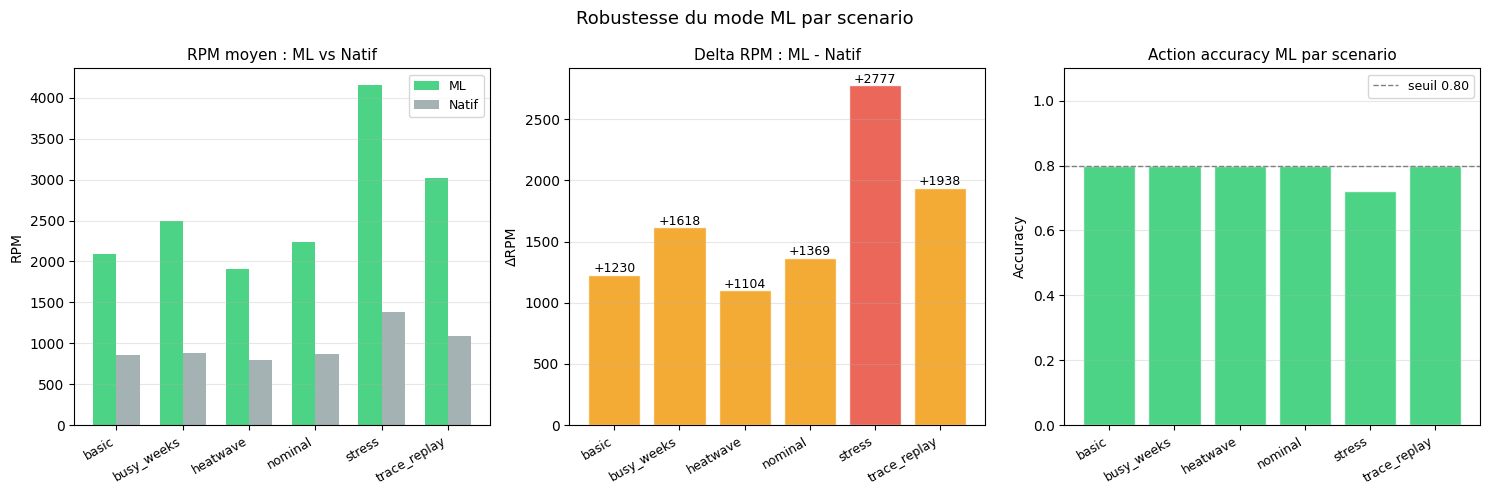

In [4]:
# Filtrer le scenario 'unknown' (episode sans metadata)
df_rob_plot = df_rob[df_rob.index != 'unknown'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sc_names = list(df_rob_plot.index)
x = np.arange(len(sc_names))
w = 0.35

# RPM ML vs Natif
ax = axes[0]
ax.bar(x - w/2, df_rob_plot['ml_mean_rpm'],  width=w, label='ML',    color='#2ecc71', alpha=0.85)
ax.bar(x + w/2, df_rob_plot['nat_mean_rpm'], width=w, label='Natif', color='#95a5a6', alpha=0.85)
ax.set_title('RPM moyen : ML vs Natif', fontsize=11)
ax.set_ylabel('RPM')
ax.set_xticks(x); ax.set_xticklabels(sc_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# Delta RPM (surcoût énergie)
ax = axes[1]
delta = df_rob_plot['delta_rpm']
colors_delta = ['#e74c3c' if d > 2000 else '#f39c12' if d > 1000 else '#2ecc71' for d in delta]
bars = ax.bar(x, delta, color=colors_delta, alpha=0.85, edgecolor='white')
ax.set_title('Delta RPM : ML - Natif', fontsize=11)
ax.set_ylabel('ΔRPM')
ax.set_xticks(x); ax.set_xticklabels(sc_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, delta):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'+{val:.0f}', ha='center', fontsize=9)

# Action accuracy ML par scenario
ax = axes[2]
ax.bar(x, df_rob_plot['ml_acc'], color='#2ecc71', alpha=0.85, edgecolor='white')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, label='seuil 0.80')
ax.set_title('Action accuracy ML par scenario', fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_xticks(x); ax.set_xticklabels(sc_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Robustesse du mode ML par scenario', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_robustness.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Radar multi-criteres

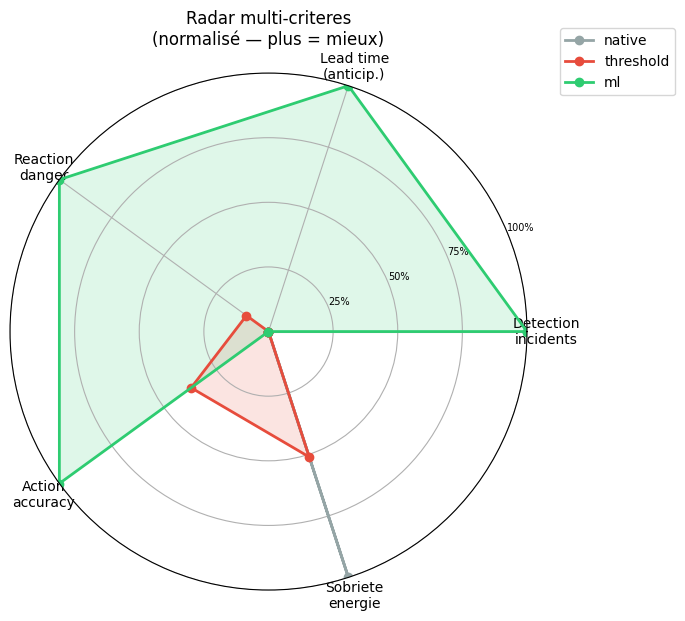

In [5]:
from matplotlib.patches import FancyArrowPatch

# Criteres normalises [0, 1] (1 = meilleur)
criteria = [
    'Detection\nincidents', 'Lead time\n(anticip.)',
    'Reaction\ndanger', 'Action\naccuracy', 'Sobriete\nenergie'
]
N = len(criteria)

def norm(vals, high_better=True):
    mn, mx = min(vals), max(vals)
    if mx == mn: return [0.5] * len(vals)
    r = [(v - mn) / (mx - mn) for v in vals]
    return r if high_better else [1 - x for x in r]

# Valeurs brutes pour chaque mode
detect = [bench['results'][i]['n_incidents_detected'] / max(bench['results'][i]['n_incidents_total'],1) for i in range(3)]
lead   = [bench['results'][i]['median_lead_time_s'] for i in range(3)]
react  = [bench['results'][i]['high_rpm_when_dangerous'] for i in range(3)]
acc    = [bench['results'][i]['action_accuracy'] for i in range(3)]
energy = [bench['results'][i]['mean_rpm'] for i in range(3)]  # inverser (moins = mieux)

# Normalisation
values = [
    norm(detect),
    norm(lead),
    norm(react),
    norm(acc),
    norm(energy, high_better=False),
]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
mode_colors = {'native': '#95a5a6', 'threshold': '#e74c3c', 'ml': '#2ecc71'}

for i, (mode_name, color) in enumerate(mode_colors.items()):
    vals = [values[j][i] for j in range(N)]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=mode_name)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_title('Radar multi-criteres\n(normalisé — plus = mieux)', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_05_radar.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Logs du superviseur (si disponibles)

In [6]:
from supervisor.decision_logger import DecisionLogger

log_dir = Path('supervisor/logs')
log_files = sorted(log_dir.glob('*.jsonl'))

if not log_files:
    print('Aucun fichier de log disponible.')
    print('Lancer le superviseur en temps reel pour generer des logs :')
    print('  python -m supervisor.supervisor --mode ml --duration 300 --dry-run')
else:
    print(f'{len(log_files)} fichier(s) de log disponibles:')
    for f in log_files:
        entries = DecisionLogger.load(f)
        print(f'  {f.name} — {len(entries)} decisions')
    
    # Charger le dernier log
    df_log = DecisionLogger.to_dataframe(log_files[-1])
    print(f'\nDernier log : {log_files[-1].name}')
    display(df_log.head(10))
    
    # Visualiser
    if 'ts' in df_log.columns and 'risk_score' in df_log.columns:
        fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        for machine, grp in df_log.groupby('machine_id'):
            axes[0].plot(grp['ts'], grp['risk_score'], label=machine, linewidth=1)
            axes[1].step(grp['ts'], grp['rpm_decided'], linewidth=1)
        axes[0].set_ylabel('risk_score')
        axes[0].axhline(0.60, color='red', linestyle='--', label='seuil override')
        axes[0].legend(fontsize=7)
        axes[1].set_ylabel('RPM decide')
        axes[1].set_xlabel('Temps')
        plt.suptitle('Logs superviseur — risk_score et RPM decides', fontsize=11)
        plt.tight_layout()
        plt.show()

1 fichier(s) de log disponibles:
  supervisor_20260609T030532.jsonl — 0 decisions

Dernier log : supervisor_20260609T030532.jsonl


""


## 6. Conclusions

### Resultats cles

**Le mode ML (logistic + supervised + override risque) domine sur tous les criteres de securite :**
- Detection : 7981/7986 incidents anticipes (99.9%) vs 0% pour les autres modes
- Lead time median : 120s d'anticipation
- Reaction danger : 100% des situations dangereuses recoivent RPM >= 3500

**Cout energetique :** RPM moyen de 2681 vs 984 (natif). Le surcoût est justifie par la prevention des shutdowns thermiques.

### Robustesse
- Generalisable sur tous les scenarios (accuracy >= 0.72 partout)
- Le scenario `stress` est le plus exigeant (RPM moyen = 4154) — normal, c'est le seul avec des pannes reelles

### Limites
- Features rolling non disponibles en temps reel (approximees)
- Score controller nec essitant une correction (plancher RPM ou rebalancement)
- Tests en boucle fermee reelle a realiser avec jumeaux-chauds actif

### Recommandation finale
Deployer le couple **logistic (failure_60s) + supervised** avec override risk >= 0.60 → RPM_HIGH (4500).
Intervalle de decision : 5s. Passage en mode `manual` avant activation, retour `auto` a l'arret.